In [1]:
from google.colab import drive
drive.mount('/content/gdrive', force_remount=True)

Mounted at /content/gdrive


In [65]:
import os
os.chdir("/content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/")

In [3]:
%%capture
!pip install optuna torch plotly botorch

In [4]:
# Import Packages
import os
import pandas as pd
import datetime
import time
import warnings
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import optuna
import matplotlib.pyplot as plt
import pickle as pkl

In [5]:
from src.preprocessing.data_preparation import DataPreparation
from src.preprocessing.feature_scaling import robust_scaling, min_max_scaling
from src.preprocessing.feature_engineering import feature_encoding, create_temporal_features, create_lag_features, expanding_mean_std_weighted_avg
from src.utils.helper_functions import get_approach
from src.model.base_model.tcn_model import TCNModel
from src.utils.evaluate import evaluate_model
from src.utils.train import train
from src.utils.test import test
from src.utils.postprocessing import process_data
from src.utils.metrics import performance_metrics
from src.model.transfer_model.feature_extractor import FeatureExtractor, extract_features
from src.model.transfer_model.transfer_tcn_model import TransferTCNModel
from src.utils.line_plotting import create_line_plot

In [6]:
warnings.filterwarnings("ignore")

# Set seed for numpy
SEED = 1

# # Set seed for PyTorch
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

In [7]:
def objective(trial, epochs):

    num_channels = trial.suggest_categorical('num_channels',
                                             [[2 ** i] * (j + 1) for i in range(4, 7) for j in range(0, 2)])
    kernel_size = trial.suggest_int('kernel_size', 2, 5)
    dropout = trial.suggest_float('dropout', 0.2, 0.5)
    learning_rate = trial.suggest_float('learning_rate', 1e-5, 1e-1, log=True)
    batch_size = trial.suggest_categorical('batch_size', [64, 128, 256])
    epochs = epochs

    train_loader = torch.utils.data.DataLoader(transfer_train_data, batch_size=batch_size, shuffle=False)
    val_loader = torch.utils.data.DataLoader(transfer_val_data, batch_size=batch_size, shuffle=False)
    test_loader = torch.utils.data.DataLoader(transfer_test_data, batch_size=batch_size, shuffle=False)

    # create the model
    model = TransferTCNModel(input_size=transfer_train_features.shape[2], output_size=transfer_y_train.shape[1], num_channels=num_channels,
                kernel_size=kernel_size, dropout=dropout).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    loss_fn = nn.MSELoss()

    train_loss = []
    val_loss = []

    # train the model
    for epoch in range(epochs):
        # training
        model.train()
        epoch_train_loss = []
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)
            optimizer.zero_grad()
            outputs = model(inputs.permute(0, 2, 1))
            loss = loss_fn(outputs, targets)
            loss.backward()
            optimizer.step()
            epoch_train_loss.append(loss.item())
        avg_train_loss = sum(epoch_train_loss) / len(epoch_train_loss)
        train_loss.append(avg_train_loss)

        # validation
        model.eval()
        epoch_val_loss = []
        with torch.no_grad():
            for inputs, targets in val_loader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs.permute(0, 2, 1))
                loss = loss_fn(outputs, targets)
                epoch_val_loss.append(loss.item())
        avg_val_loss = sum(epoch_val_loss) / len(epoch_val_loss)
        val_loss.append(avg_val_loss)

        # print progress
        trial.report(avg_val_loss, epoch)
        if trial.should_prune():
            raise optuna.exceptions.TrialPruned()

        # Save the hyperparameters and metrics for each trial
        trial.set_user_attr("num_channels", num_channels)
        trial.set_user_attr("kernel_size", kernel_size)
        trial.set_user_attr("dropout", dropout)
        trial.set_user_attr("learning_rate", learning_rate)
        trial.set_user_attr("batch_size", batch_size)
        trial.set_user_attr(f"train_loss_epoch_{epoch}", avg_train_loss)
        trial.set_user_attr(f"val_loss_epoch_{epoch}", avg_val_loss)

    return avg_val_loss

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}\n")

Device: cpu



In [66]:
# os.chdir("/content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/script/transfer_model/")
# current_directory = os.getcwd()
# os.chdir("../../")
# root_dir = os.getcwd()

'/content/gdrive/.shortcut-targets-by-id/1LqEo8pUuYb2m6_azWXScdNlW_RzO5fgh/Asif_Trasfer_Learing_ACN_Data/DeepKale/experiments_0.2/script/transfer_model'

In [9]:
if os.path.exists('/mnt/work/dkale/dkale_Colab/experiments_0.2/'):
    # Define root directory path
    root_dir = '/mnt/work/dkale/dkale_Colab/experiments_0.2/'
else:
    root_dir = '/content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/'

current_date = datetime.datetime.now().strftime("%d%m%Y")
approach = get_approach(model_type=1)

In [10]:
used_model = "TCN"
model_version = "1.0"
loss_function_name = "MSE"
optimization_technique = "OP"
github_issue_no = "4.0"

In [70]:
# Define subdirectories
root_data_dir = root_dir + 'data/'
preprocessed_dir = root_data_dir + 'preprocessed/ACN/'
train_val_test_dir = root_data_dir + 'train_val_test/ACN/'
transfer_train_val_test_dir = train_val_test_dir + 'transfer_model'
result_dir = root_dir + 'result/'

# Base Directories
base_result_dir = result_dir + 'base_result/'
base_model_dir = base_result_dir + 'model/'

# Transfer Directories
transfer_train_val_test_dir = train_val_test_dir + 'transfer_model/'
transfer_result_dir = result_dir + 'transfer_result/'
transfer_model_dir = transfer_result_dir + 'model/'
transfer_loss_metrics_dir = transfer_result_dir + 'loss_metrics'
transfer_permormance_metrics_dir = transfer_result_dir + 'performance_metrics'
transfer_trial_metrics_dir = transfer_result_dir + 'trial_metrics'
transfer_test_result_dir = transfer_result_dir + 'test_result'

In [12]:
# Define parameters
HOURS = 24
PAST_DAYS = 7
FUTURE_DAYS = 1
N_PAST = HOURS * PAST_DAYS
N_FUTURE = HOURS * FUTURE_DAYS
EPOCHS = 2
PATIENCE = 3
LAYER_INDEX =2

N_TRIALS = 100

In [13]:
study_name = f"Transfer Model, Used Model: {used_model}, Model Version: {model_version}, Loss Function: {loss_function_name}, Optimization Technique: {optimization_technique}, PAST DAYS: {PAST_DAYS} ---> FUTURE DAYS: {FUTURE_DAYS}"
common_file_name = f"{approach}_{used_model}_{model_version}_{loss_function_name}_{optimization_technique}_{github_issue_no}_{PAST_DAYS}.0_{FUTURE_DAYS}.0_{current_date}"

In [14]:
col_order = ['connectionTime', 'kWhDelivered_Smoothed', 'total_charging_time_Smoothed', 'idle_time_Smoothed', 'siteID_0', 'siteID_1', 'siteID_1_2', 'siteID_2',\
                           'siteID_19', 'Time_of_day_0_4', 'Time_of_day_4_8', 'Time_of_day_8_12', 'Time_of_day_12_16', 'Time_of_day_16_20', 'Time_of_day_20_24', 'Sunday', 'Monday',\
                            'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Weekday', 'Weekend', 'Season', 'Daylight_Saving_Time', 'lag_1', 'lag_2', 'expanding_mean',\
                            'expanding_std', 'weighted_avg', 'Hour_of_Day_sin', 'Hour_of_Day_cos', 'Day_Of_Week_sin', 'Day_Of_Week_cos', 'Day_Of_year_sin', 'Day_Of_year_cos',\
                            'Month_Of_Year_sin', 'Month_Of_Year_cos']

In [15]:
base_model_name = 'TL_BM_TCN_1.0_MSE_BO_4.0_7.0_1.0_23062023.pt'
# define the path to save the model
base_model_path = os.path.join(base_model_dir, base_model_name)

In [16]:
transfer_df = pd.read_csv(rf'{preprocessed_dir}acn_office_0.2_0.1_22_06_2023.csv')

In [17]:
transfer_df = feature_encoding(transfer_df)

In [18]:
transfer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8500 entries, 0 to 8499
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype         
---  ------                        --------------  -----         
 0   connectionTime                8500 non-null   datetime64[ns]
 1   kWhDelivered_Smoothed         8500 non-null   float64       
 2   total_charging_time_Smoothed  8500 non-null   float64       
 3   idle_time_Smoothed            8500 non-null   float64       
 4   siteID_0                      8500 non-null   int64         
 5   siteID_19                     8500 non-null   int64         
dtypes: datetime64[ns](1), float64(3), int64(2)
memory usage: 398.6 KB


In [19]:
transfer_df['siteID_1'] = 0
transfer_df['siteID_1_2'] = 0
transfer_df['siteID_2'] = 0

In [20]:
transfer_df = create_temporal_features(transfer_df)

In [21]:
transfer_df["lag_1"] = transfer_df['kWhDelivered_Smoothed'].shift(1)
transfer_df["lag_2"] = transfer_df['kWhDelivered_Smoothed'].shift(2)

In [22]:
transfer_df = expanding_mean_std_weighted_avg(dataframe = transfer_df, window_size = 2)

In [23]:
transfer_robust_cols = ['kWhDelivered_Smoothed', 'total_charging_time_Smoothed', 'idle_time_Smoothed', 'lag_1', 'lag_2', 'expanding_mean', 'expanding_std', 'weighted_avg']
transfer_sin_cos_cols = ['Hour_of_Day', 'Day_Of_Week', 'Day_Of_year', 'Month_Of_Year']
transfer_scaled_df, transfer_robust_scaling_params = robust_scaling(df = transfer_df, robust_cols = transfer_robust_cols, sin_cos_cols = transfer_sin_cos_cols)

In [24]:
transfer_connection_time_list = transfer_scaled_df["connectionTime"].tolist()

In [25]:
second_df_cols = transfer_scaled_df.columns.tolist()
new_cols = [col for col in col_order if col in second_df_cols]
transfer_scaled_df = transfer_scaled_df.loc[:, new_cols]

In [26]:
# Convert number of days to number of hours
transfer_test_size = 45 * HOURS  #45 days
transfer_val_size = 2232 # 30% of the remaining data (93 days) ---> Train size (216 days)

# Calculate the index to split the data
transfer_train_index = len(transfer_scaled_df) - transfer_test_size - transfer_val_size
transfer_val_index = transfer_train_index + transfer_val_size

# Split the data into training, validation, and testing sets
transfer_train_df = transfer_scaled_df.iloc[:transfer_train_index]
transfer_val_df = transfer_scaled_df.iloc[transfer_train_index:transfer_val_index]
transfer_test_df = transfer_scaled_df.iloc[transfer_val_index:]

In [27]:
# Write the dataframes to separate CSV files
transfer_train_df.to_csv(
        rf'{transfer_train_val_test_dir}acn_office_train_0.2_0.1_22_06_2023.csv',
        index=False)
transfer_val_df.to_csv(
        rf'{transfer_train_val_test_dir}acn_office_val_0.2_0.1_22_06_2023.csv',
        index=False)
transfer_test_df.to_csv(
        rf'{transfer_train_val_test_dir}acn_office_test_0.2_0.1_22_06_2023.csv',
        index=False)

TRANSFER_TRAIN_FILE_NAME = rf'{transfer_train_val_test_dir}acn_office_train_0.2_0.1_22_06_2023.csv'
TRANSFER_VAL_FILE_NAME = rf'{transfer_train_val_test_dir}acn_office_val_0.2_0.1_22_06_2023.csv'
TRANSFER_TEST_FILE_NAME = rf'{transfer_train_val_test_dir}acn_office_test_0.2_0.1_22_06_2023.csv'

In [28]:
dp = DataPreparation(n_future= N_FUTURE, n_past= N_PAST)

In [29]:
transfer_x_train, transfer_y_train = dp.prepare_data(dataframe = transfer_train_df)
transfer_x_val, transfer_y_val = dp.prepare_data(dataframe = transfer_val_df)
transfer_x_test, transfer_y_test = dp.prepare_data(dataframe = transfer_test_df)

In [30]:
transfer_x_train, transfer_y_train = transfer_x_train[:100], transfer_y_train[:100]
transfer_x_val, transfer_y_val = transfer_x_val[:100], transfer_y_val[:100]
transfer_x_test, transfer_y_test = transfer_x_test[:100], transfer_y_test[:100]

In [31]:
transfer_y_train.shape

(100, 24)

In [32]:
base_model = TCNModel(
    input_size=transfer_x_train.shape[2],
    output_size=transfer_y_train.shape[1],
    num_channels=[32] * 4,
    kernel_size=3,
    dropout=0.30131441354751587
).to(device)

# create optimizer and loss function
base_optimizer = torch.optim.Adam(base_model.parameters(), lr=0.0029837472829967737)
base_loss_fn = nn.MSELoss()

In [33]:
feature_extractor = FeatureExtractor(model = base_model, layer_index = LAYER_INDEX)

In [34]:
transfer_train_features = extract_features(torch.from_numpy(transfer_x_train).float().to(device), feature_extractor)
transfer_val_features = extract_features(torch.from_numpy(transfer_x_val).float().to(device), feature_extractor)
transfer_test_features = extract_features(torch.from_numpy(transfer_x_test).float().to(device), feature_extractor)

In [35]:
transfer_y_train = torch.from_numpy(transfer_y_train).float()
transfer_y_val = torch.from_numpy(transfer_y_val).float()
transfer_y_test = torch.from_numpy(transfer_y_test).float()

In [36]:
transfer_train_data = TensorDataset(transfer_train_features, transfer_y_train)
transfer_val_data = TensorDataset(transfer_val_features, transfer_y_val)
transfer_test_data = TensorDataset(transfer_test_features, transfer_y_test)

In [37]:
print("Hyperparameter Searching started..................\n")
study = optuna.create_study(study_name=study_name, direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(lambda trial: objective(trial, epochs=EPOCHS), n_trials=N_TRIALS)
print("\n")

[I 2023-06-23 19:43:14,685] A new study created in memory with name: Transfer Model, Used Model: TCN, Model Version: 1.0, Loss Function: MSE, Optimization Technique: OP, PAST DAYS: 7 ---> FUTURE DAYS: 1


Hyperparameter Searching started..................



[I 2023-06-23 19:43:15,121] Trial 0 finished with value: 1.5364762544631958 and parameters: {'num_channels': [16, 16], 'kernel_size': 2, 'dropout': 0.30366821811291433, 'learning_rate': 0.00038642916535526494, 'batch_size': 256}. Best is trial 0 with value: 1.5364762544631958.
[I 2023-06-23 19:43:15,304] Trial 1 finished with value: 1.3366969227790833 and parameters: {'num_channels': [16, 16], 'kernel_size': 2, 'dropout': 0.25943044672546367, 'learning_rate': 0.015957993164212966, 'batch_size': 64}. Best is trial 1 with value: 1.3366969227790833.
[I 2023-06-23 19:43:15,448] Trial 2 finished with value: 2.5383377075195312 and parameters: {'num_channels': [16, 16], 'kernel_size': 2, 'dropout': 0.32633228750151566, 'learning_rate': 0.06785129181994787, 'batch_size': 128}. Best is trial 1 with value: 1.3366969227790833.
[I 2023-06-23 19:43:15,930] Trial 3 finished with value: 1.447228193283081 and parameters: {'num_channels': [64], 'kernel_size': 3, 'dropout': 0.4367837985354466, 'learning

In [38]:
trials = study.trials
results = []

for trial in trials:
    hyperparameters = {
        "num_channels": trial.user_attrs.get("num_channels"),
        "kernel_size": trial.user_attrs.get("kernel_size"),
        "dropout": trial.user_attrs.get("dropout"),
        "learning_rate": trial.user_attrs.get("learning_rate"),
        "batch_size": trial.user_attrs.get("batch_size")
    }

    epoch_losses = []
    num_epochs = 0
    while True:
        epoch_train_loss = trial.user_attrs.get(f"train_loss_epoch_{num_epochs}", None)
        epoch_val_loss = trial.user_attrs.get(f"val_loss_epoch_{num_epochs}", None)

        if epoch_train_loss is not None and epoch_val_loss is not None:
            epoch_loss = {
                "epoch": num_epochs,
                "train_loss": epoch_train_loss,
                "val_loss": epoch_val_loss
            }
            epoch_losses.append(epoch_loss)
            num_epochs += 1
        else:
            break

    result = {
        "trial_number": trial.number,
        "val_loss": trial.value,
        "hyperparameters": hyperparameters,
        "epoch_losses": epoch_losses
    }

    results.append(result)

In [39]:
trial_result_file = f"{common_file_name}_trial_loss_metrics.pkl"
trial_result_path = os.path.join(transfer_trial_metrics_dir, trial_result_file)

with open(trial_result_path, "wb") as f:
    pkl.dump(results, f)

print(f"Transfer Trial results: '{trial_result_file}' has been successfully saved: {trial_result_path}.\n")

Transfer Trial results: 'TL_TM_TCN_1.0_MSE_OP_4.0_7.0_1.0_23062023_trial_loss_metrics.pkl' have been successfully saved: /content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/result/transfer_result/trial_metrics/TL_TM_TCN_1.0_MSE_OP_4.0_7.0_1.0_23062023_trial_loss_metrics.pkl.



In [40]:
print(f'  Best trial: {study.best_trial.number}')
print(f'  num_channels: {study.best_trial.params["num_channels"]}')
print(f'  kernel_size: {study.best_trial.params["kernel_size"]}')
print(f'  dropout: {study.best_trial.params["dropout"]}')
print(f'  learning_rate: {study.best_trial.params["learning_rate"]}')
print(f'  batch_size: {study.best_trial.params["batch_size"]}\n')

  Best trial: 34
  num_channels: [16]
  kernel_size: 2
  dropout: 0.34294692716077557
  learning_rate: 0.02824218707971539
  batch_size: 128



In [41]:
# train the model with the best hyperparameters
best_num_channels = study.best_trial.params["num_channels"]
best_kernel_size = study.best_trial.params["kernel_size"]
best_dropout = study.best_trial.params["dropout"]
best_learning_rate = study.best_trial.params["learning_rate"]
best_batch_size = study.best_trial.params["batch_size"]

In [42]:
transfer_train_loader = torch.utils.data.DataLoader(transfer_train_data, batch_size=best_batch_size, shuffle=False)
transfer_val_loader = torch.utils.data.DataLoader(transfer_val_data, batch_size=best_batch_size, shuffle=False)
transfer_test_loader = torch.utils.data.DataLoader(transfer_test_data, batch_size=best_batch_size, shuffle=False)

In [43]:
transfer_model = TransferTCNModel(
        input_size=transfer_train_features.shape[2],
        output_size=transfer_y_train.shape[1],
        num_channels=best_num_channels,
        kernel_size=best_kernel_size,
        dropout=best_dropout
    ).to(device)

# create optimizer and loss function
transfer_optimizer = torch.optim.Adam(transfer_model.parameters(), lr=best_learning_rate)
transfer_loss_fn = nn.MSELoss()

In [44]:
# train the model
transfer_train_loss, transfer_val_loss = train(
    device = device,
    model=transfer_model,
    optimizer=transfer_optimizer,
    loss_fn=transfer_loss_fn,
    train_loader=transfer_train_loader,
    val_loader=transfer_val_loader,
    epochs=EPOCHS,
    patience=PATIENCE,
    filename=os.path.join(transfer_loss_metrics_dir, f'{common_file_name}_loss_metrics.pkl')
)


Training started........................

Epoch 1/2, Train Loss: 0.3451, Val Loss: 1.2855
Epoch 2/2, Train Loss: 0.3251, Val Loss: 1.2596


Train and validation losses have been saved to: /content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/result/transfer_result/loss_metrics/TL_TM_TCN_1.0_MSE_OP_4.0_7.0_1.0_23062023_loss_metrics.pkl



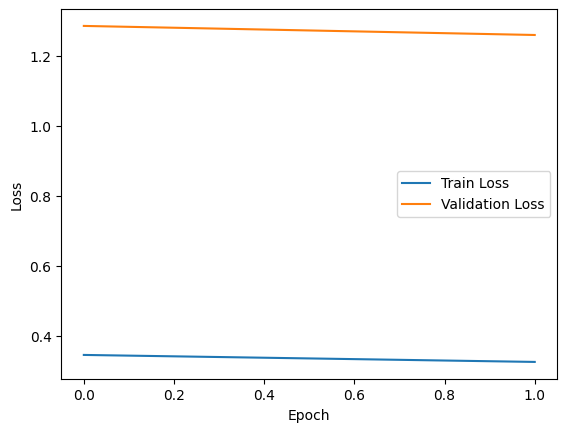

In [45]:
plt.plot(transfer_train_loss, label='Train Loss')
plt.plot(transfer_val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

In [46]:
transfer_model_name = f'{common_file_name}.pt'
# define the path to save the model
transfer_model_path = os.path.join(transfer_model_dir, transfer_model_name)

In [47]:
# save the model to the specified path
if not os.path.exists(os.path.dirname(transfer_model_path)):
    os.makedirs(os.path.dirname(transfer_model_path))
torch.save(transfer_model.state_dict(), transfer_model_path)
print(f'The transfer trained model: {transfer_model_name} has been successfully saved: "{transfer_model_path}".\n')

The transfer trained model: TL_TM_TCN_1.0_MSE_OP_4.0_7.0_1.0_23062023.pt has been successfully saved: "/content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/result/transfer_result/model/TL_TM_TCN_1.0_MSE_OP_4.0_7.0_1.0_23062023.pt".



In [48]:
if os.path.exists(transfer_model_path):
    transfer_model.load_state_dict(torch.load(transfer_model_path))
    transfer_test_loss, transfer_y_pred = test(device = device, model = transfer_model, test_loader = transfer_test_loader, loss_fn = transfer_loss_fn)
else:
    print(f"File not found at path: {transfer_model_path}\n")

Test Loss: 1.9144



In [49]:
transfer_result_df, transfer_result_df_daily = process_data(
    y_test=transfer_y_test,
    y_pred=transfer_y_pred,
    scaling_type = 'robust',
    scaling_params=transfer_robust_scaling_params,
    connection_time_list=transfer_connection_time_list,
    train_df=transfer_train_df,
    val_df=transfer_val_df,
    scaled_df=transfer_scaled_df,
    n_past=N_PAST,
    n_future=N_FUTURE
)

In [50]:
# Save transfer_result_df as pickle
transfer_result_df_file_name = f'{common_file_name}_transfer_result_df.pkl'
transfer_result_df_file_path = os.path.join(transfer_test_result_dir, transfer_result_df_file_name)
transfer_result_df.to_pickle(transfer_result_df_file_path)
print(f"Transfer result DataFrame {transfer_result_df_file_name} has been successfully saved: {transfer_result_df_file_path}.\n")

# Save transfer_result_df_daily as pickle
transfer_result_df_daily_file_name = f'{common_file_name}_transfer_result_df_daily.pkl'
transfer_result_df_daily_file_path = os.path.join(transfer_test_result_dir, transfer_result_df_daily_file_name)
transfer_result_df_daily.to_pickle(transfer_result_df_daily_file_path)
print(f"Transfer result daily DataFrame {transfer_result_df_daily_file_name} has been successfully saved: {transfer_result_df_daily_file_path}.\n")

Transfer result DataFrame TL_TM_TCN_1.0_MSE_OP_4.0_7.0_1.0_23062023_transfer_result_df.pkl has been successfully saved: /content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/result/transfer_result/test_result/TL_TM_TCN_1.0_MSE_OP_4.0_7.0_1.0_23062023_transfer_result_df.pkl.

Transfer result daily DataFrame TL_TM_TCN_1.0_MSE_OP_4.0_7.0_1.0_23062023_transfer_result_df_daily.pkl has been successfully saved: /content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/result/transfer_result/test_result/TL_TM_TCN_1.0_MSE_OP_4.0_7.0_1.0_23062023_transfer_result_df_daily.pkl.



In [51]:
transfer_mae, transfer_r2, transfer_mse, transfer_rms = performance_metrics(result_df = transfer_result_df_daily)

In [52]:
print(f"Transfer MAE: {transfer_mae}")
print(f"Transfer R2 score: {transfer_r2}")
print(f"Transfer MSE: {transfer_mse}")
print(f"Transfer RMS: {transfer_rms}\n")

Transfer MAE: 1.4639289379119873
Transfer R2 score: -1.463332446088442
Transfer MSE: 3.1714797019958496
Transfer RMS: 1.7808648747156113



In [53]:
performance_metrics_file_name = f'{common_file_name}_performance_metrics.pkl'
performance_metrics_file_path = os.path.join(transfer_permormance_metrics_dir, performance_metrics_file_name)
# save the performance metrics in a separate pickle file
with open(performance_metrics_file_path, 'wb') as f:
    '''Saving the performance matrix'''
    pkl.dump({'transfer test_loss':transfer_test_loss, 'transfer mae': transfer_mae, 'transfer r2': transfer_r2, 'transfer mse': transfer_mse, 'transfer rms': transfer_rms}, f)

print(f"Performance metrics for transfer model: {performance_metrics_file_name} has been successfully saved: {performance_metrics_file_path}.\n")

Performance metrics for transfer model: TL_TM_TCN_1.0_MSE_OP_4.0_7.0_1.0_23062023_performance_metrics.pkl has been successfully saved: /content/gdrive/My Drive/TL_A/DeepKale/experiments_0.2/result/transfer_result/performance_metrics/TL_TM_TCN_1.0_MSE_OP_4.0_7.0_1.0_23062023_performance_metrics.pkl.



In [54]:
create_line_plot(transfer_result_df_daily, title = 'Actual vs Predicted kWh Delivered Avg Daily-Transfer TCN Model')